## Chapter 2 - Applied

Let's review some key formulas from this chapter before moving on to the exercises.
<br></br>

**Mean Squared Error (MSE)**

$$
MSE = \frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{f}(x_i) \right)^2
$$

**The Bias-Variance Trade-Off**

$$
E \left( y_0 - \hat{f} (x_0) \right)^2 = Var( \hat{f}(x_0)) + [Bias( \hat{f}(x_0))]^2 + Var( \epsilon)
$$
<br></br>


### Question 8

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
import seaborn as sns

#### 8a)

In [2]:
# Load dataset
college = pd.read_csv('data/College.csv')

#### 8b)

In [3]:
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [4]:
# Adapting column into index & renaming it
college2 = pd.read_csv('data/College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'college'}, axis=1)
college3.columns = [x.lower() for x in college3.columns]
college3 = college3.set_index('college')
college3

,private,apps,accept,enroll,top10perc,top25perc,f.undergrad,p.undergrad,outstate,room.board,books,personal,phd,terminal,s.f.ratio,perc.alumni,expend,grad.rate
college,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49


In [5]:
college = college3

#### 8c)

In [6]:
college.describe()

,apps,accept,enroll,top10perc,top25perc,f.undergrad,p.undergrad,outstate,room.board,books,personal,phd,terminal,s.f.ratio,perc.alumni,expend,grad.rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


#### 8d)

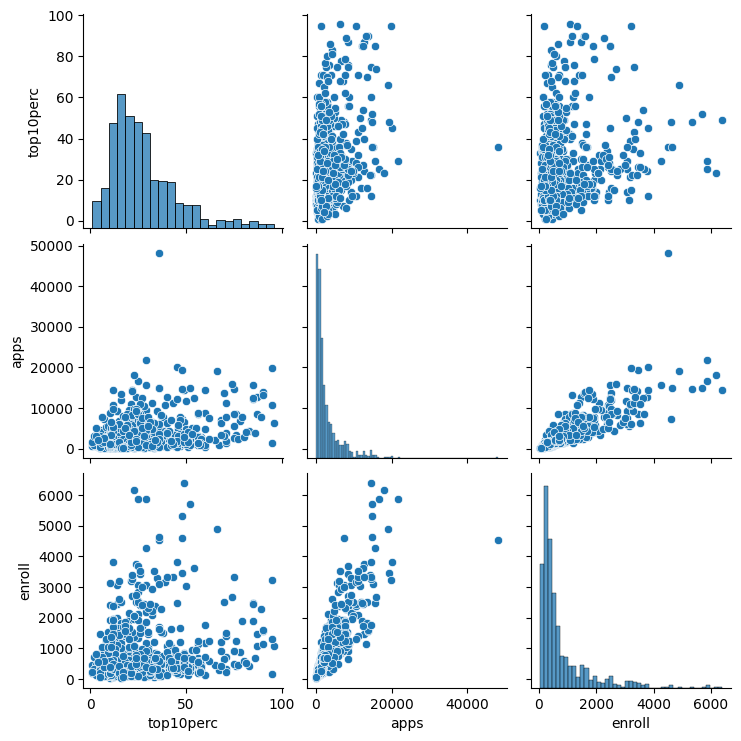

In [7]:
# Plot requested columns
columns = ['top10perc', 'apps', 'enroll']
sns.pairplot(college[columns]);

#### 8e)

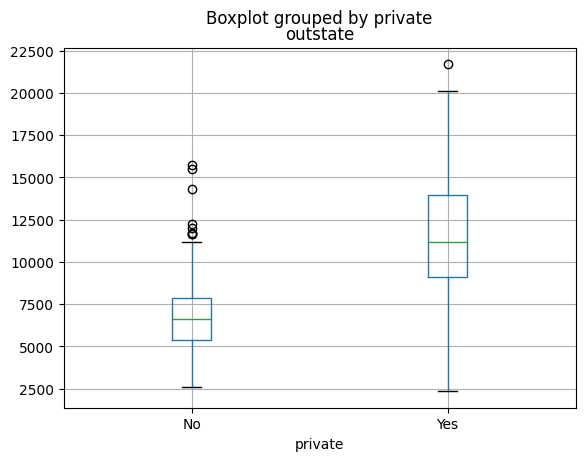

In [8]:
college.boxplot('outstate', by='private');

#### 8f)

In [9]:
# Create 'elite' from 'top10perc'
college['elite'] = college['top10perc'].apply(
    lambda x: 'No' if x <= 50 else 'Yes'
)

# Count values
college['elite'].value_counts()

elite
No     699
Yes     78
Name: count, dtype: int64

#### 8g)

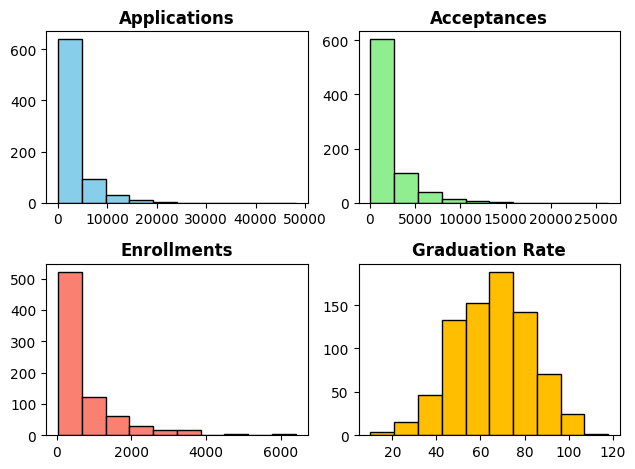

In [10]:
fig, axes = plt.subplots(2, 2)
axes[0,0].hist(college['apps'], color='skyblue', edgecolor='black')
axes[0,0].set_title('Applications', fontweight='bold')

axes[0,1].hist(college['accept'], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Acceptances', fontweight='bold')

axes[1,0].hist(college['enroll'], color='salmon', edgecolor='black')
axes[1,0].set_title('Enrollments', fontweight='bold')

axes[1,1].hist(college['grad.rate'], color='#FFBF00', edgecolor='black')
axes[1,1].set_title('Graduation Rate', fontweight='bold')

plt.tight_layout()
plt.show();

#### 8h)

In [11]:
for column in college.columns:
    print(college[column].describe())
    print('')

count     777
unique      2
top       Yes
freq      565
Name: private, dtype: object

count      777.000000
mean      3001.638353
std       3870.201484
min         81.000000
25%        776.000000
50%       1558.000000
75%       3624.000000
max      48094.000000
Name: apps, dtype: float64

count      777.000000
mean      2018.804376
std       2451.113971
min         72.000000
25%        604.000000
50%       1110.000000
75%       2424.000000
max      26330.000000
Name: accept, dtype: float64

count     777.000000
mean      779.972973
std       929.176190
min        35.000000
25%       242.000000
50%       434.000000
75%       902.000000
max      6392.000000
Name: enroll, dtype: float64

count    777.000000
mean      27.558559
std       17.640364
min        1.000000
25%       15.000000
50%       23.000000
75%       35.000000
max       96.000000
Name: top10perc, dtype: float64

count    777.000000
mean      55.796654
std       19.804778
min        9.000000
25%       41.000000
50%       54.

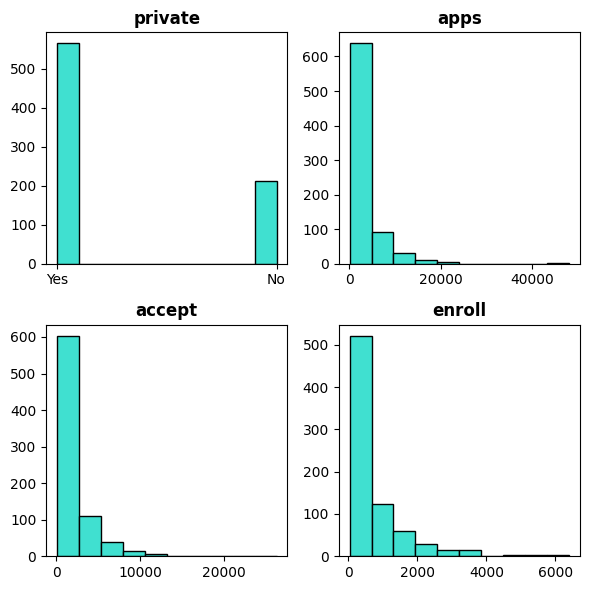

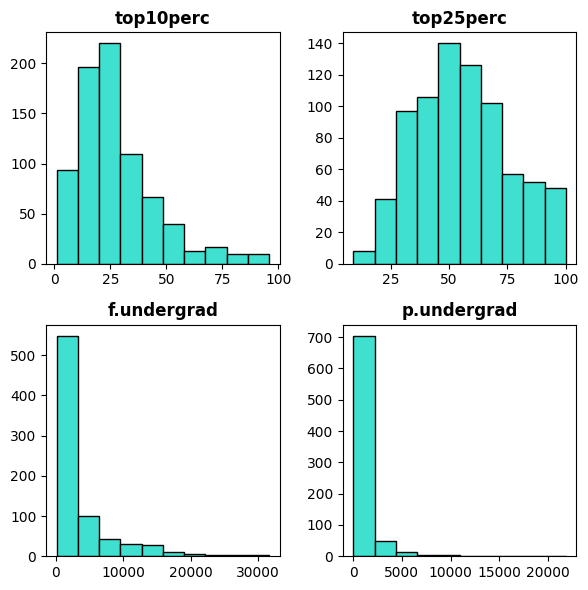

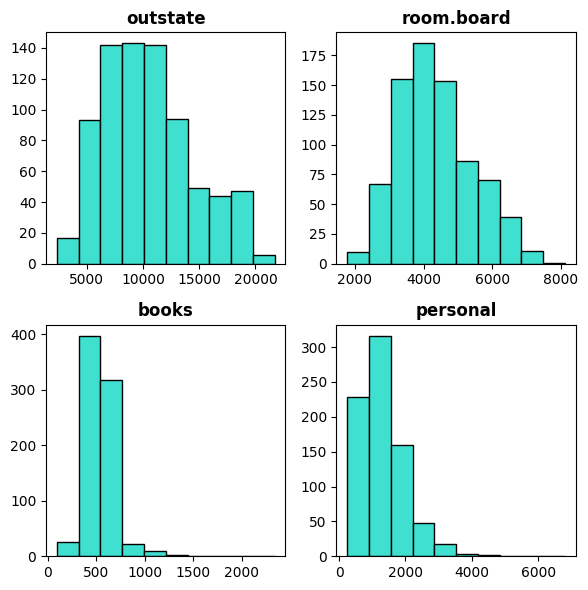

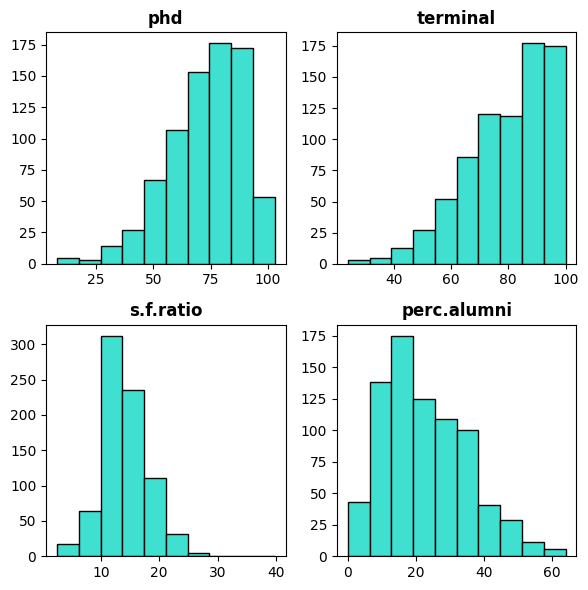

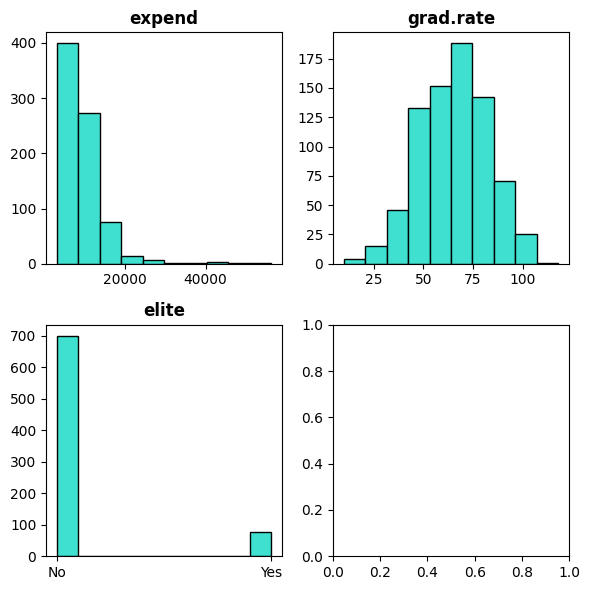

In [12]:
for i,column in enumerate(college.columns):
    if i % 4 == 0:
        _, axes = plt.subplots(2, 2, figsize=(6,6))
    # Determine row & column
    row = (i % 4) // 2
    col = (i % 4) % 2
    # Plot histogram
    axes[row, col].hist(college[column], color='#40E0D0', edgecolor='black')
    axes[row, col].set_title(f'{column}', fontweight='bold')
    # Show the plot after every 4 columns or at the end
    if (i % 4 == 3) | (i == len(college.columns) - 1):
        plt.tight_layout()
        plt.show()

**<u>Private vs Public Institutions</u>**
- A majority of the institutions are private: **565 out of 777** colleges.

**<u>Applications</u>**
- Most colleges receive between **0–1,558 applications**.
- **Mean**: 3,001  
- **Median**: 1,558  
- Increasing the number of bins in the histogram would help show this distribution more clearly.

**<u>Acceptances</u>**
- Colleges typically accept between **0–1,110 applicants**.
- **Mean**: 2,028  
- **Median**: 1,110

**<u>Enrollments</u>**
- The number of enrolled students follows a decreasing trend:
    - Applications > Acceptances > Enrollments
- **Mean**: 779  
- **Median**: 434

**<u>Top 10% of High School Class</u>**
- While only 10% of students nationwide are in the top 10% of their high school class, we see a higher concentration of them going to colleges.
- This suggests many students with lower performance may not attend college, while top performers usually do.
- One college reports **96%** of its students from the top 10%.
- **Mean**: 27.55%  
- **Median**: 23%

**<u>Top 25% of High School Class</u>**
- Follows a similar pattern to the top 10%, indicating an overrepresentation of higher-performing high school students in college populations.

**<u>Full-Time vs Part-Time Undergraduates</u>**

| Type       | Mean  | Median |
|------------|-------|--------|
| Full-time  | 3,699 | 1,707  |
| Part-time  | 855   | 353    |

**<u>Out-of-State Tuition & Room & Board</u>**

| Variable       | Mean    | Median |
|----------------|---------|--------|
| Out-of-state   | $10,440 | $9,990 |
| Room & Board   | $4,357  | $4,200 |

**<u>Books</u>**
- **Mean**: $549  
- **Median**: $500

**<u>Personal Expenses</u>**
- **Mean**: $1,340  
- **Median**: $1,200

**<u>Instructional Expenditure per Student</u>**
- **Mean**: $9,660  
- **Median**: $8,377

**<u>Graduation Rate</u>**
- Despite the high costs of college, the average graduation rate is only **65%**, which also matches the **median**.
- This implies that about **one-third of students do not complete** their degrees.



---

### Question 9

#### 9a)

In [13]:
# Load & quick inspect data
auto = pd.read_csv('data/Auto.csv')
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [14]:
# Check unique values for 'horsepower'
np.unique(auto['horsepower'])

array(['100', '102', '103', '105', '107', '108', '110', '112', '113',
       '115', '116', '120', '122', '125', '129', '130', '132', '133',
       '135', '137', '138', '139', '140', '142', '145', '148', '149',
       '150', '152', '153', '155', '158', '160', '165', '167', '170',
       '175', '180', '190', '193', '198', '200', '208', '210', '215',
       '220', '225', '230', '46', '48', '49', '52', '53', '54', '58',
       '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70',
       '71', '72', '74', '75', '76', '77', '78', '79', '80', '81', '82',
       '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93',
       '94', '95', '96', '97', '98', '?'], dtype=object)

In [15]:
# Remove '?' & adapt data type
auto = auto[auto['horsepower'] != '?']
auto['horsepower'] = auto['horsepower'].astype('int')
auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


In [16]:
# Check unique values for 'origin'
np.unique(auto['origin'])

array([1, 2, 3])

A first quick look at the data reveals that all columns but 'name' and 'year' are quantitative. But as we have seen before, 'cylinders' may be considered qualitative due to so few, or fixed, numerical values. This is also the case for 'origin'.

So, we can say that 'name', 'cylinders' and 'origin' are qualitative and all other columns are quantitative.

#### 9b)

In [17]:
# Split columns
columns_qual = [
    'name',
    'cylinders',
    'year',
    'origin'
]
columns_quant = [
    col for col in auto.columns if col not in columns_qual
]

# Iterate over columns_quant to get info
for column in columns_quant:
    # Get values
    column_min = auto[column].min()
    column_max = auto[column].max()

    # Print information
    split = '-' * len(column)
    print(column + '\n' + split)
    print(f'column_min: {column_min} \ncolumn_max: {column_max}\n')

mpg
---
column_min: 9.0 
column_max: 46.6

displacement
------------
column_min: 68.0 
column_max: 455.0

horsepower
----------
column_min: 46 
column_max: 230

weight
------
column_min: 1613 
column_max: 5140

acceleration
------------
column_min: 8.0 
column_max: 24.8



#### 9c)

In [18]:
# Iterate over columns_quant to get info
for column in columns_quant:
    
    # Get information
    split = '-' * len(column)
    mean = f'mean: \t{auto[column].mean():.2f}'
    std = f'std: \t{auto[column].std():.2f}'
    
    # Print
    print(column + '\n' + split)
    print(mean + '\n' + std + '\n')

mpg
---
mean: 	23.45
std: 	7.81

displacement
------------
mean: 	194.41
std: 	104.64

horsepower
----------
mean: 	104.47
std: 	38.49

weight
------
mean: 	2977.58
std: 	849.40

acceleration
------------
mean: 	15.54
std: 	2.76



#### 9d)

In [19]:
# Filter data (10th-85th observation)
auto_filtered = auto.drop(auto.iloc[9:85].index)

# Iterate over columns_quant to get info
for column in columns_quant:
    
    # Get information
    split = '-' * len(column)
    mean = f'mean: \t{auto_filtered[column].mean():.2f}'
    std = f'std: \t{auto_filtered[column].std():.2f}'
    
    # Print
    print(column + '\n' + split)
    print(mean + '\n' + std + '\n')

mpg
---
mean: 	24.40
std: 	7.87

displacement
------------
mean: 	187.24
std: 	99.68

horsepower
----------
mean: 	100.72
std: 	35.71

weight
------
mean: 	2935.97
std: 	811.30

acceleration
------------
mean: 	15.73
std: 	2.69



#### 9e)

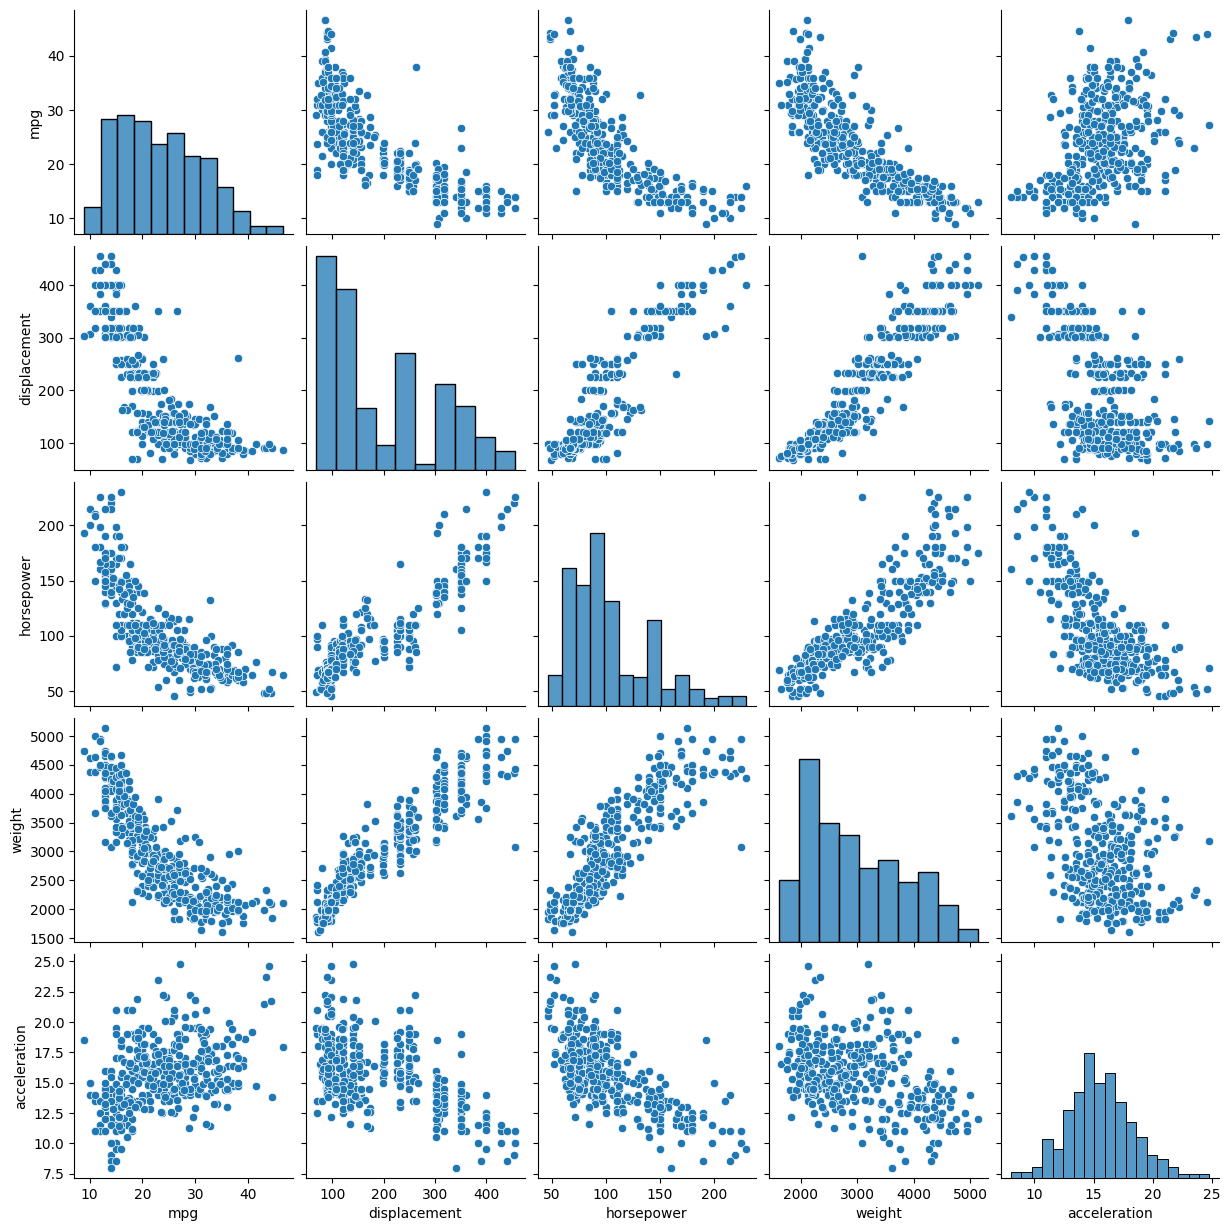

In [21]:
sns.pairplot(auto[columns_quant]);

It is possible to see linear, non-linear and, less common, little relationship between features.

**<u>Linear Relationship</u>**
- displacement vs weight
- displacement vs horsepower
- horsepower vs weight
- horsepower vs acceleration
- acceleration vs horsepower

**<u>Non-Linear Relationship</u>**
- mpg vs weight
- mpg vs horsepower
- mpg vs displacement

**<u>Some or No Relationship</u>**
- mpg vs acceleration
- weight vs acceleration 

#### 9f)

As previously mentioned, we can see a non-linear relation between 'mpg' and 'weight', 'horsepower' and 'displacement'. There is also seem to have a less distinguishable relation betwee 'mpg' and 'acceleration'. So, overall, all of the quantitative features reveal a pattern/relationship with 'mpg'.

---

### Question 10

#### 10a)

In [22]:
# Load dataset
boston = pd.read_csv('data/Boston.csv')

#### 10b)

In [23]:
# Get dataset's shape
boston.shape

(506, 14)

The dataset has 506 rows and 14 columns. Each row represents an observation and each column a feature.

#### 10c)

In [24]:
# Quick info
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [25]:
# Check first observations
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


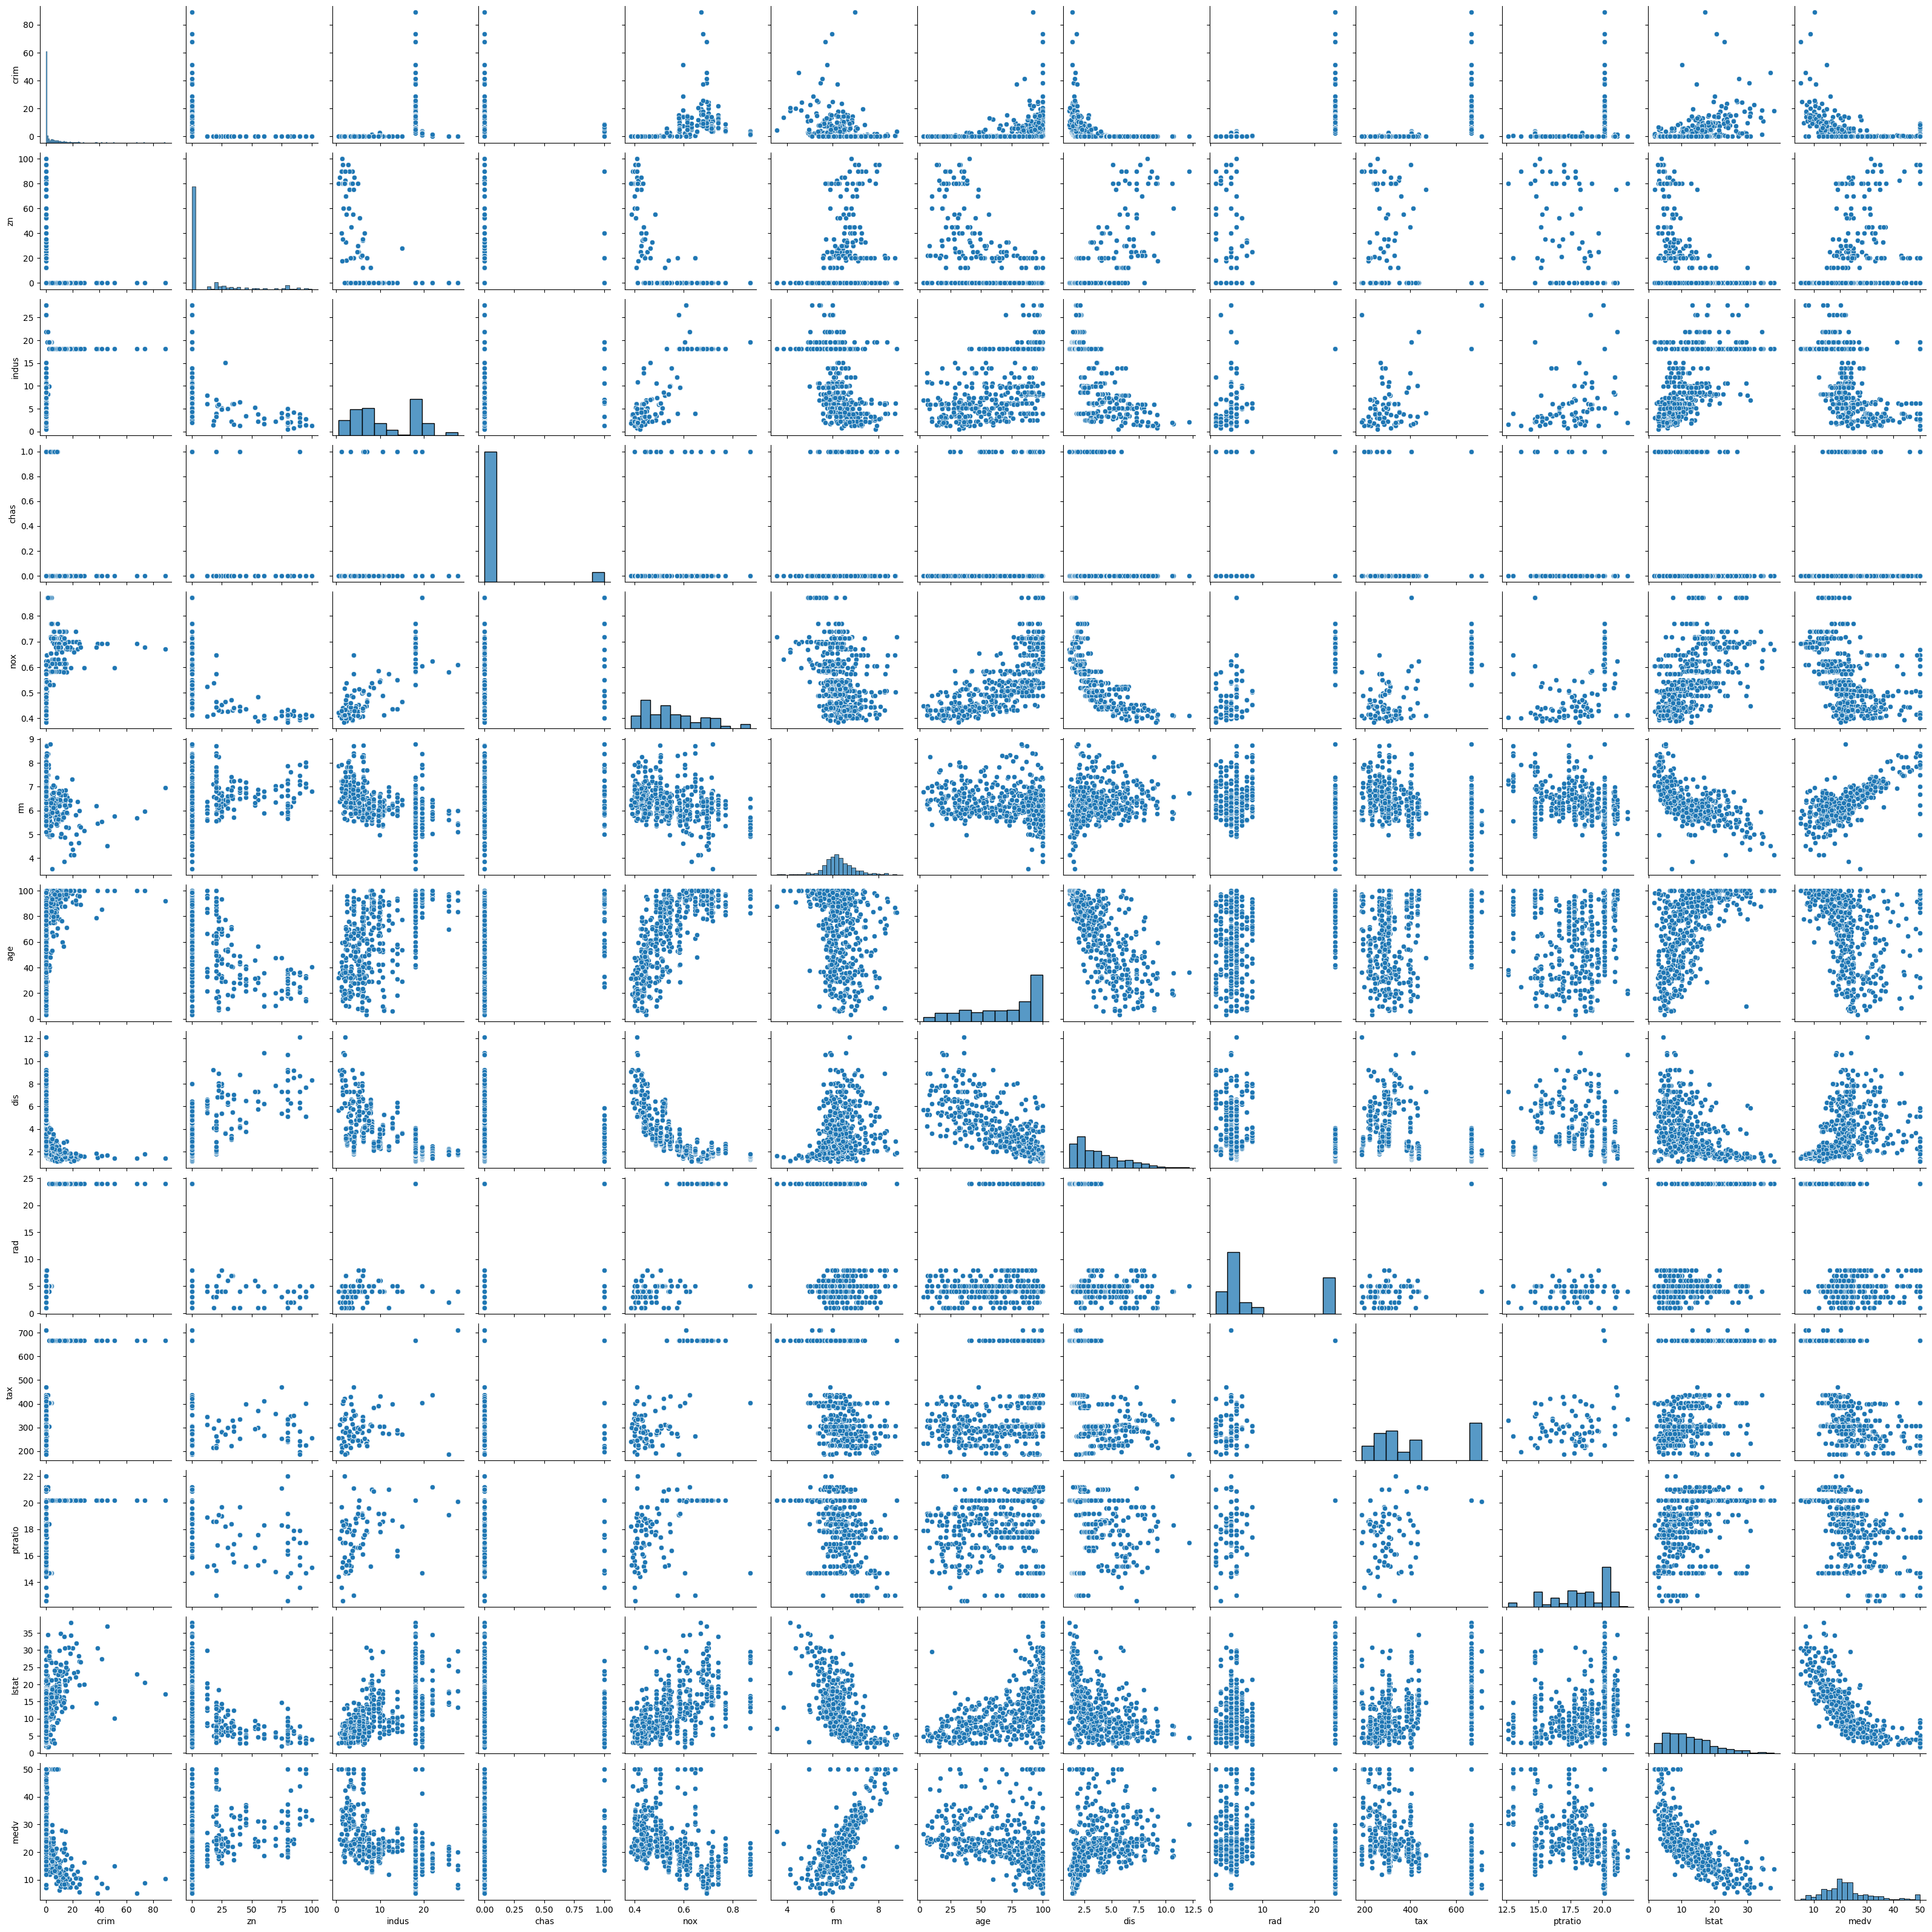

In [26]:
# Remove column/feature
boston = boston.iloc[:, 1:]

# Plot
sns.pairplot(boston);

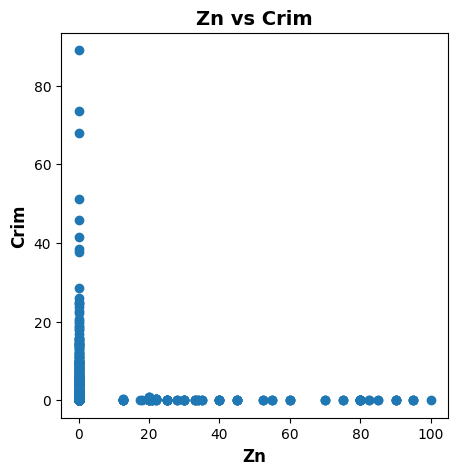

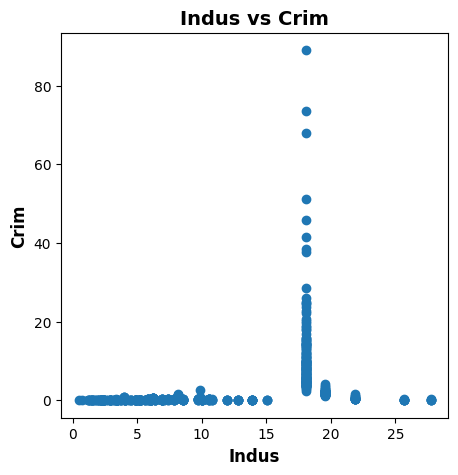

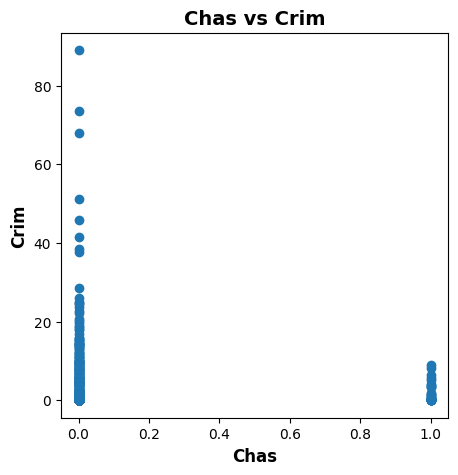

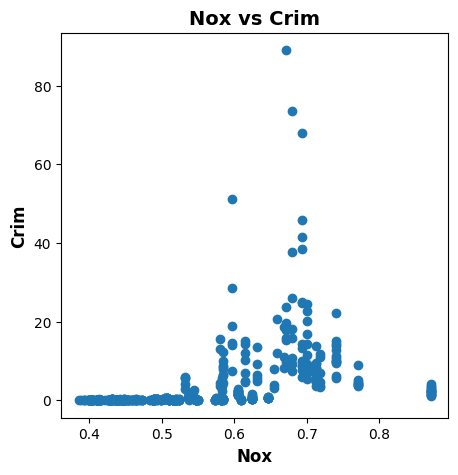

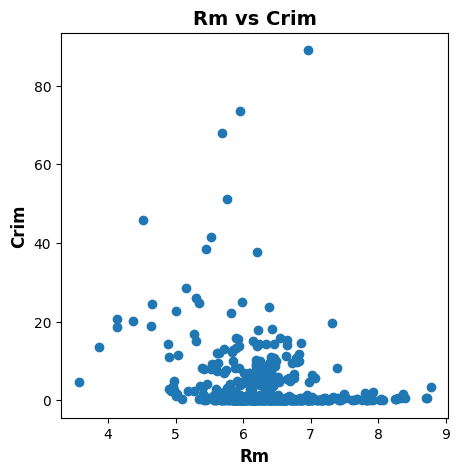

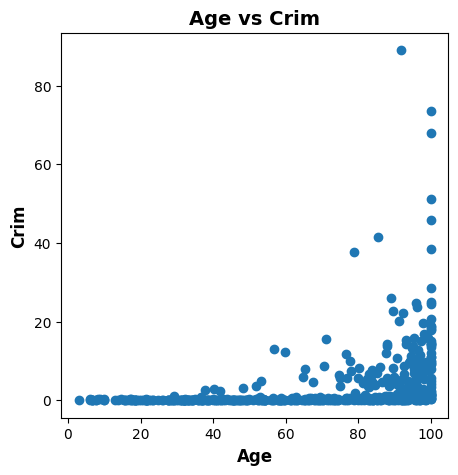

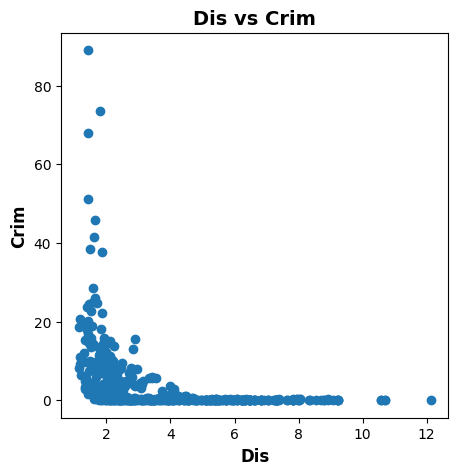

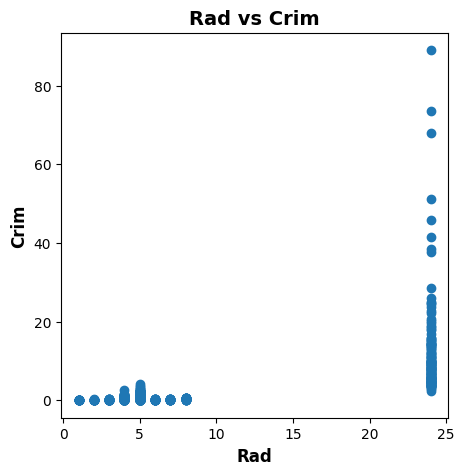

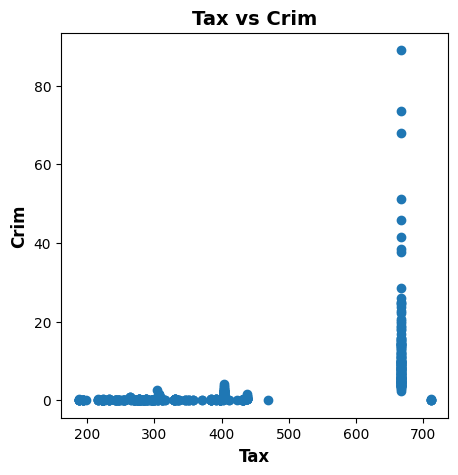

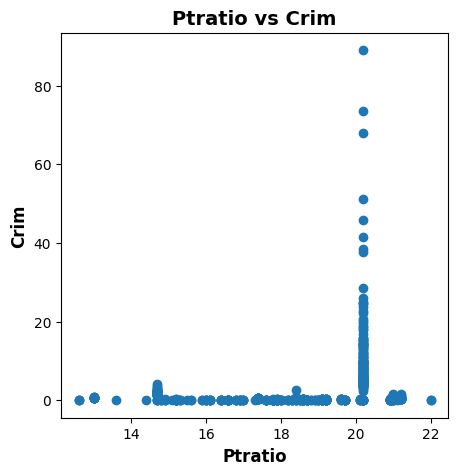

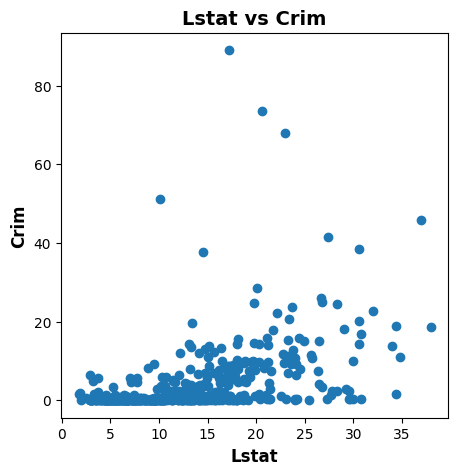

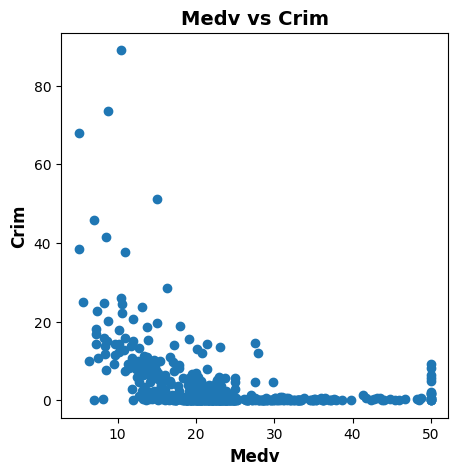

In [29]:
# Iterate over columns plotting scatterplots
columns = [x for x in boston.columns if x != 'crim']
for column in columns:

    # Get labels
    y_label = 'Crim'
    x_label = column[0].upper() + column[1:]

    # Create fiture
    plt.figure(figsize=(5,5))
    plt.scatter(boston[column], boston['crim'])
    plt.title(f'{x_label} vs {y_label}', fontsize=14, fontweight='bold')
    plt.xlabel(f'{x_label}', fontsize=12, fontweight='bold')
    plt.ylabel(f'{y_label}', fontsize=12, fontweight='bold')
    plt.show();

#### 10d)

It is possible to observe some relationships between 'crim' and other features in the dataset.

For example, 'crim' tends to be lower when 'chas' is equal to 1, compared to when it is 0. Similarly, when 'zn' is equal to 0, the 'crim' is higher than for other values. This pattern appears across several features, where a specific value seems to drive much of the variation of 'crim'.

Some features appear to have a more structure or continuous relationship with 'crim'. For example, 'age' shows a positive association with 'crim'. A similar trend is observed iwth 'lstat', which also seems to correlate positively with 'crim'.

Overall, it is challenging to identify clear linear or structured relationships. Instead, the data often suggest clustering or regional patterns that may infulence crime rates more than individual variables alone.

#### 10e)

As described above, when investigating the dataset with scatterplots we see clusters driving much of the variation of 'crim'. This seem associated with a particularly region. Let us confirm with further exploration.

In [139]:
columns = [
    'crim',
    'tax',
    'ptratio'
]
for column in columns:
    print(boston[column].describe())
    print('\n')

count    506.000000
mean       3.613524
std        8.601545
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max       88.976200
Name: crim, dtype: float64


count    506.000000
mean     408.237154
std      168.537116
min      187.000000
25%      279.000000
50%      330.000000
75%      666.000000
max      711.000000
Name: tax, dtype: float64


count    506.000000
mean      18.455534
std        2.164946
min       12.600000
25%       17.400000
50%       19.050000
75%       20.200000
max       22.000000
Name: ptratio, dtype: float64




In [140]:
# Check observation with highest 'crim'
boston[boston['crim'] == boston['crim'].max()]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
380,88.9762,0.0,18.1,0,0.671,6.968,91.9,1.4165,24,666,20.2,17.21,10.4


The highest 'tax' value observed is 711, meanwhile the median is 330. The highest 'ptratio' is 22, not much higher than the median of 19. In contrast, the highest 'crim' value is 88.97, which is staggeringly higher than the median of 0.25.

The highest 'crim' value comes from observation/suburb #380.

#### 10f)

In [ ]:
boston['chas'].sum()

35

We have 35 suburbs that bound the Charles river.

#### 10g)

As seen before, 19 is the median pupil-teacher ratio.

#### 10h)


In [142]:
boston[boston['medv'] == boston['medv'].min()]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0


We have 2 observations with the same minimum value of 5 for 'medv'. Both shares similar stats:

- The observation with the lowest 'medv' also exhibits a very high 'crim'.
- It has 0 residential land zoned for large lots ('zn' = 0).
- It shows a high 'indus' value, indicating a large proportion of non-retail business land.
- It has the highest 'age', meaning nearly all housing units were built before 1940.
- Its location suggests it is close to one or more Boston employment centers (low 'dis' value).
- It has the highest 'rad' value, reflecting maximum accessibility to radial highways.
- The 'tax' rate is high, suggesting an increased financial burden on homeowners.
- The 'ptratio' is also elevated.
- It has a high lower status of the population 'lstat'.



#### 10i)

In [143]:
# Filter for relevant suburbs
rm_bigger7 = boston[boston['rm'] > 7]
rm_bigger8 = boston[boston['rm'] > 8]

# Print information
print(f"""
More than 7 rooms per dwelling: {len(rm_bigger7)}
More than 8 rooms per dwelling: {len(rm_bigger8)}
""")


More than 7 rooms per dwelling: 64
More than 8 rooms per dwelling: 13



In [144]:
# Check basic stats on more than 8 rooms
rm_bigger8.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,4.310000,44.200000
std,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,1.373566,8.092383
min,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,2.470000,21.900000
25%,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,3.320000,41.700000
50%,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,4.140000,48.300000
75%,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,5.120000,50.000000
max,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,7.440000,50.000000


In [145]:
# Check basic stats on the entire dataset
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


Compared to the overall dataset, suburbs with more than 8 rooms per dwelling have a lower average 'crim' but a higher median value. Their 'tax' are relatively similar, while 'ptratio' is generally lower.